# 🎬 Multi-Modal Video Analyzer - Complete Demo

**Purpose:** Demonstrate how to combine Computer Vision (OCR) and Natural Language Processing (NLP) for video analysis.

**What This Demonstrates:**
- Multi-modal AI (combining vision + language)
- Computer vision with EasyOCR
- NLP with GPT-4
- Data fusion across modalities
- Production-ready pipeline architecture

**Technologies:**
- `opencv-python` - Video processing & frame extraction
- `easyocr` - Deep learning OCR (CRAFT + recognition network)
- `openai` - GPT-4 for language understanding
- `Python` - System integration

---

## 📋 Pipeline Overview

```
Video File
    ↓
Frame Extraction (OpenCV)
    ↓
Visual Analysis (EasyOCR) → Key Terms, Numbers, Text
    ↓
Text Analysis (GPT-4) → Claims, Tone, Entities
    ↓
Multi-Modal Fusion → Combined Report
    ↓
Export (JSON/Markdown)
```

---

## 1️⃣ Setup: Install & Import

In [1]:
# Install required packages (run once)
!pip install opencv-python easyocr openai python-dotenv pillow numpy tqdm matplotlib ipywidgets

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com



[notice] A new release of pip is available: 23.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Standard library imports
import os
import json
import re
from pathlib import Path
from typing import List, Dict, Any, Tuple
from collections import Counter
from dataclasses import dataclass, field
from datetime import datetime

# Third-party imports
import cv2
import numpy as np
import easyocr
from openai import OpenAI
from dotenv import load_dotenv
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Display settings
from IPython.display import display, Markdown, HTML

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2️⃣ Configuration

In [3]:
# Load environment variables
load_dotenv()

# API Configuration
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
if not OPENAI_API_KEY:
    print("⚠️  WARNING: OPENAI_API_KEY not found in .env file")
    print("Create a .env file with: OPENAI_API_KEY=your_key_here")
else:
    print("✅ OpenAI API key loaded")

# Initialize OpenAI client
client = OpenAI(api_key=OPENAI_API_KEY)

# Directory structure
DATA_DIR = Path("./data")
VIDEOS_DIR = DATA_DIR / "videos"
FRAMES_DIR = DATA_DIR / "output" / "frames"
REPORTS_DIR = DATA_DIR / "output" / "reports"

# Create directories
VIDEOS_DIR.mkdir(parents=True, exist_ok=True)
FRAMES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n📁 Directory structure:")
print(f"  Videos: {VIDEOS_DIR}")
print(f"  Frames: {FRAMES_DIR}")
print(f"  Reports: {REPORTS_DIR}")

✅ OpenAI API key loaded

📁 Directory structure:
  Videos: data\videos
  Frames: data\output\frames
  Reports: data\output\reports


## 3️⃣ Data Classes

Define structured data formats for our pipeline.

In [4]:
@dataclass
class OCRResult:
    """Single OCR detection result"""
    text: str
    confidence: float
    bbox: List[List[int]]
    frame_number: int
    
    def to_dict(self) -> Dict[str, Any]:
        return {
            'text': self.text,
            'confidence': float(self.confidence),
            'bbox': [[int(x) for x in point] for point in self.bbox],
            'frame_number': int(self.frame_number)
        }


@dataclass
class VisualSummary:
    """Summary of visual analysis (OCR results)"""
    total_frames: int
    frames_with_text: int
    unique_text_blocks: int
    extracted_text: List[OCRResult]
    key_frames: List[int]
    detected_terms: List[str]
    numbers_found: List[Dict[str, Any]]
    
    def to_dict(self) -> Dict[str, Any]:
        return {
            'total_frames': int(self.total_frames),
            'frames_with_text': int(self.frames_with_text),
            'unique_text_blocks': int(self.unique_text_blocks),
            'extracted_text': [r.to_dict() for r in self.extracted_text],
            'key_frames': [int(f) for f in self.key_frames],
            'detected_terms': self.detected_terms,
            'numbers_found': [
                {
                    'value': n['value'],
                    'numeric': float(n['numeric']),
                    'is_percentage': bool(n['is_percentage']),
                    'is_price': bool(n['is_price']),
                    'context': n['context'],
                    'frame': int(n['frame']),
                    'confidence': float(n['confidence'])
                }
                for n in self.numbers_found
            ]
        }


@dataclass
class TextSummary:
    """Summary of text analysis (NLP results)"""
    summary: str
    tone: str  # positive, negative, neutral
    claims: List[Dict[str, Any]]
    entities: List[str]
    key_points: List[str]
    
    def to_dict(self) -> Dict[str, Any]:
        return {
            'summary': self.summary,
            'tone': self.tone,
            'claims': self.claims,
            'entities': self.entities,
            'key_points': self.key_points
        }


@dataclass
class MultiModalReport:
    """Final fused report combining visual and text analysis"""
    video_name: str
    timestamp: str
    quality_score: float
    visual_summary: Dict[str, Any]
    text_summary: Dict[str, Any]
    all_entities: List[str]
    insights: List[str]
    
    def to_dict(self) -> Dict[str, Any]:
        return {
            'video_name': self.video_name,
            'timestamp': self.timestamp,
            'quality_score': self.quality_score,
            'visual_summary': self.visual_summary,
            'text_summary': self.text_summary,
            'all_entities': self.all_entities,
            'insights': self.insights
        }

print("✅ Data classes defined")

✅ Data classes defined


## 4️⃣ Frame Extraction Functions

Extract frames from video using OpenCV.

In [5]:
def extract_frames(video_path: Path, output_dir: Path, fps: float = 0.5) -> int:
    """
    Extract frames from video at specified FPS
    
    Args:
        video_path: Path to video file
        output_dir: Where to save frames
        fps: Frames per second to extract (0.5 = 1 frame every 2 seconds)
    
    Returns:
        Number of frames extracted
    """
    # Clear existing frames
    for old_frame in output_dir.glob("*.jpg"):
        old_frame.unlink()
    
    print(f"🎬 Opening video: {video_path.name}")
    
    # Open video with OpenCV
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {video_path}")
    
    # Get video properties
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / video_fps
    
    print(f"📊 Video info:")
    print(f"  FPS: {video_fps:.2f}")
    print(f"  Total frames: {total_frames:,}")
    print(f"  Duration: {duration:.1f} seconds ({duration/60:.1f} minutes)")
    print(f"  Extracting at: {fps} FPS (1 frame every {1/fps:.0f} seconds)")
    
    # Calculate frame interval
    frame_interval = int(video_fps / fps)
    expected_frames = total_frames // frame_interval
    print(f"  Expected frames to extract: ~{expected_frames}")
    
    # Extract frames
    frame_count = 0
    saved_count = 0
    
    with tqdm(total=expected_frames, desc="Extracting frames") as pbar:
        while True:
            ret, frame = cap.read()
            
            if not ret:
                break
            
            # Save frame at specified interval
            if frame_count % frame_interval == 0:
                frame_filename = output_dir / f"frame_{saved_count:04d}.jpg"
                cv2.imwrite(str(frame_filename), frame)
                saved_count += 1
                pbar.update(1)
            
            frame_count += 1
    
    cap.release()
    
    print(f"\n✅ Extracted {saved_count} frames to {output_dir}")
    return saved_count


def show_sample_frames(frames_dir: Path, num_samples: int = 4):
    """
    Display sample frames from extracted frames
    """
    frame_files = sorted(list(frames_dir.glob("*.jpg")))
    
    if not frame_files:
        print("No frames found")
        return
    
    # Select evenly spaced samples
    if len(frame_files) <= num_samples:
        samples = frame_files
    else:
        step = len(frame_files) // num_samples
        samples = [frame_files[i * step] for i in range(num_samples)]
    
    # Display
    fig, axes = plt.subplots(1, len(samples), figsize=(15, 4))
    if len(samples) == 1:
        axes = [axes]
    
    for ax, frame_path in zip(axes, samples):
        frame = cv2.imread(str(frame_path))
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax.imshow(frame_rgb)
        ax.set_title(frame_path.stem)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Showing {len(samples)} sample frames from {len(frame_files)} total frames")

print("✅ Frame extraction functions defined")

✅ Frame extraction functions defined


## 5️⃣ Computer Vision (OCR) Functions

Extract text from frames using EasyOCR.

In [6]:
def preprocess_image(image: np.ndarray) -> np.ndarray:
    """
    Preprocess image for better OCR
    - Convert to grayscale
    - Apply sharpening
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Sharpen for clearer text
    kernel = np.array([[-1,-1,-1],
                      [-1, 9,-1],
                      [-1,-1,-1]])
    sharpened = cv2.filter2D(gray, -1, kernel)
    
    return sharpened


def detect_key_terms(ocr_results: List[OCRResult]) -> List[str]:
    """
    Detect key terms and entities from OCR text
    """
    terms = set()
    
    # Pattern for capitalized words/acronyms (likely important terms)
    term_pattern = re.compile(r'\b[A-Z][A-Z]+\b|\b[A-Z][a-z]+\b')
    
    # Common words to exclude
    excluded_words = {
        'THE', 'AND', 'FOR', 'WITH', 'FROM', 'THIS', 'THAT',
        'ARE', 'WAS', 'NOT', 'BUT', 'CAN', 'YOU', 'ALL', 'NEW',
        'NOW', 'OUT', 'GET', 'GOT', 'HAS', 'HAD', 'HOW', 'WHY',
        'WHEN', 'WHERE', 'WHAT', 'WHO'
    }
    
    for result in ocr_results:
        # Find capitalized words
        matches = term_pattern.findall(result.text)
        
        for match in matches:
            # Include if not a common word and length >= 2
            if match not in excluded_words and len(match) >= 2:
                terms.add(match)
    
    return sorted(list(terms))


def extract_numbers(ocr_results: List[OCRResult]) -> List[Dict[str, Any]]:
    """
    Extract numbers, prices, percentages from OCR text
    """
    numbers = []
    
    # Patterns for various number formats
    number_patterns = [
        r'\$[\d,]+\.?\d*[kKmMbB]?',  # Prices
        r'-?\d+\.?\d*%',              # Percentages
        r'-?\d+\.?\d*[kKmMbB]',       # Abbreviated numbers
        r'-?\d{1,3}(?:,\d{3})*(?:\.\d+)?',  # Comma-separated
        r'-?\d+\.?\d*',               # Plain numbers
    ]
    
    for result in ocr_results:
        for pattern in number_patterns:
            matches = re.findall(pattern, result.text)
            
            for match in matches:
                is_percentage = '%' in match
                is_price = '$' in match
                
                # Clean for numeric conversion
                value_clean = match.replace('$', '').replace(',', '').replace('%', '')
                
                # Handle k, M, B abbreviations
                multiplier = 1
                if value_clean and value_clean[-1].upper() in ['K', 'M', 'B']:
                    multipliers = {'K': 1000, 'M': 1000000, 'B': 1000000000}
                    multiplier = multipliers.get(value_clean[-1].upper(), 1)
                    value_clean = value_clean[:-1]
                
                try:
                    numeric_value = float(value_clean) * multiplier
                    numbers.append({
                        'value': match,
                        'numeric': numeric_value,
                        'is_percentage': is_percentage,
                        'is_price': is_price,
                        'context': result.text,
                        'frame': result.frame_number,
                        'confidence': result.confidence
                    })
                except ValueError:
                    continue
    
    return numbers


def identify_key_frames(ocr_results: List[OCRResult]) -> List[int]:
    """
    Identify frames with above-average text content
    """
    frame_text_count = Counter(r.frame_number for r in ocr_results)
    
    if not frame_text_count:
        return []
    
    avg_text = sum(frame_text_count.values()) / len(frame_text_count)
    key_frames = [
        frame for frame, count in frame_text_count.items()
        if count > avg_text * 1.5
    ]
    
    return sorted(key_frames)


def analyze_frames_with_ocr(
    frames_dir: Path,
    confidence_threshold: float = 0.3
) -> VisualSummary:
    """
    Main OCR analysis function
    """
    # Initialize OCR reader
    print("🔄 Initializing EasyOCR reader...")
    print("(Downloads model on first run - may take 1-2 minutes)")
    
    reader = easyocr.Reader(['en'], gpu=False, verbose=False)
    print("✅ OCR reader initialized\n")
    
    # Get frame files
    frame_files = sorted(list(frames_dir.glob("*.jpg")) + 
                        list(frames_dir.glob("*.png")))
    
    if not frame_files:
        print("⚠️  No frames found")
        return None
    
    print(f"🔍 Analyzing {len(frame_files)} frames with OCR...")
    print(f"   Confidence threshold: {confidence_threshold}\n")
    
    all_ocr_results = []
    frames_with_text = 0
    
    for i, frame_file in enumerate(tqdm(frame_files, desc="OCR Analysis")):
        # Read image
        image = cv2.imread(str(frame_file))
        if image is None:
            continue
        
        # Preprocess
        processed = preprocess_image(image)
        
        # Perform OCR
        results = reader.readtext(processed)
        
        # Convert to OCRResult objects
        frame_results = []
        for bbox, text, confidence in results:
            if confidence >= confidence_threshold:
                frame_results.append(OCRResult(
                    text=text.strip(),
                    confidence=float(confidence),
                    bbox=bbox,
                    frame_number=i
                ))
        
        if frame_results:
            frames_with_text += 1
            all_ocr_results.extend(frame_results)
    
    print(f"\n✅ OCR complete!")
    print(f"   Frames with text: {frames_with_text}/{len(frame_files)}")
    print(f"   Total text blocks: {len(all_ocr_results)}")
    
    # Analyze extracted text
    print(f"\n🔍 Analyzing patterns...")
    terms = detect_key_terms(all_ocr_results)
    numbers = extract_numbers(all_ocr_results)
    key_frames = identify_key_frames(all_ocr_results)
    
    print(f"   Key terms found: {len(terms)}")
    print(f"   Numbers found: {len(numbers)}")
    print(f"   Key frames: {len(key_frames)}")
    
    summary = VisualSummary(
        total_frames=len(frame_files),
        frames_with_text=frames_with_text,
        unique_text_blocks=len(all_ocr_results),
        extracted_text=all_ocr_results,
        key_frames=key_frames,
        detected_terms=terms,
        numbers_found=numbers
    )
    
    return summary

print("✅ OCR functions defined")

✅ OCR functions defined


## 6️⃣ Natural Language Processing (NLP) Functions

Analyze transcript using GPT-4.

In [7]:
def analyze_tone(transcript: str, client: OpenAI) -> str:
    """
    Analyze overall tone of content
    """
    prompt = f"""
    Analyze the tone of this content.
    
    Return ONLY one word: POSITIVE, NEGATIVE, or NEUTRAL
    
    Content:
    {transcript}
    """
    
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=10
    )
    
    return response.choices[0].message.content.strip()


def extract_claims(transcript: str, client: OpenAI) -> List[Dict[str, Any]]:
    """
    Extract specific claims and statements
    """
    prompt = f"""
    Extract all specific claims from this content.
    
    For each claim, provide:
    - claim_text: The actual claim
    - claim_type: "factual", "prediction", or "opinion"
    - confidence: How verifiable (0-100)
    
    Return as a JSON array.
    
    Content:
    {transcript}
    """
    
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=1000
    )
    
    try:
        claims = json.loads(response.choices[0].message.content)
        return claims
    except:
        return []


def extract_entities(transcript: str, client: OpenAI) -> List[str]:
    """
    Extract mentioned entities (topics, tools, concepts)
    """
    prompt = f"""
    List all important entities mentioned in this content.
    Include: topics, tools, technologies, concepts, names.
    
    Return as a JSON array of strings.
    
    Content:
    {transcript}
    """
    
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=200
    )
    
    try:
        entities = json.loads(response.choices[0].message.content)
        return entities
    except:
        return []


def extract_key_points(transcript: str, client: OpenAI) -> List[str]:
    """
    Extract key points or takeaways
    """
    prompt = f"""
    Extract 3-5 key points or main takeaways from this content.
    
    Return as a JSON array of strings.
    
    Content:
    {transcript}
    """
    
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=300
    )
    
    try:
        points = json.loads(response.choices[0].message.content)
        return points
    except:
        return []


def generate_summary(transcript: str, client: OpenAI) -> str:
    """
    Generate brief summary
    """
    prompt = f"""
    Create a concise 2-3 sentence summary of this content.
    
    Content:
    {transcript}
    """
    
    response = client.chat.completions.create(
        model="gpt-4",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5,
        max_tokens=150
    )
    
    return response.choices[0].message.content.strip()


def analyze_text_with_nlp(transcript: str, client: OpenAI) -> TextSummary:
    """
    Complete NLP analysis pipeline
    """
    print("🤖 Running NLP Analysis...\n")
    
    print("1️⃣ Analyzing tone...")
    tone = analyze_tone(transcript, client)
    print(f"   Result: {tone}\n")
    
    print("2️⃣ Generating summary...")
    summary = generate_summary(transcript, client)
    print(f"   {summary}\n")
    
    print("3️⃣ Extracting claims...")
    claims = extract_claims(transcript, client)
    print(f"   Found {len(claims)} claims\n")
    
    print("4️⃣ Identifying entities...")
    entities = extract_entities(transcript, client)
    print(f"   Found: {', '.join(entities[:5])}...\n")
    
    print("5️⃣ Extracting key points...")
    key_points = extract_key_points(transcript, client)
    print(f"   {len(key_points)} key points\n")
    
    print("✅ NLP analysis complete!")
    
    return TextSummary(
        summary=summary,
        tone=tone,
        claims=claims,
        entities=entities,
        key_points=key_points
    )

print("✅ NLP functions defined")

✅ NLP functions defined


## 7️⃣ Multi-Modal Fusion Functions

Combine visual and text analysis.

In [8]:
def calculate_quality_score(
    visual_summary: VisualSummary,
    text_summary: TextSummary
) -> float:
    """
    Calculate content quality score (0-100)
    
    Factors:
    - Visual evidence (text in frames)
    - Number and quality of claims
    - Factual vs opinion ratio
    """
    score = 0
    
    # Visual evidence score (max 30 points)
    if visual_summary:
        text_ratio = visual_summary.frames_with_text / max(visual_summary.total_frames, 1)
        score += min(text_ratio * 100, 30)
    
    # Claims score (max 40 points)
    if text_summary.claims:
        factual = sum(1 for c in text_summary.claims if c.get('claim_type') == 'factual')
        total = len(text_summary.claims)
        factual_ratio = factual / max(total, 1)
        score += factual_ratio * 40
    
    # Content completeness score (max 30 points)
    has_summary = len(text_summary.summary) > 0
    has_entities = len(text_summary.entities) > 0
    has_key_points = len(text_summary.key_points) > 0
    
    completeness = sum([has_summary, has_entities, has_key_points]) / 3
    score += completeness * 30
    
    return min(score, 100)


def fuse_multimodal_data(
    video_name: str,
    visual_summary: VisualSummary,
    text_summary: TextSummary
) -> MultiModalReport:
    """
    Fuse visual and text analysis into final report
    """
    print("🔄 Fusing multi-modal data...\n")
    
    # Calculate quality score
    quality_score = calculate_quality_score(visual_summary, text_summary)
    print(f"📊 Quality Score: {quality_score:.1f}/100")
    
    # Combine entities from both sources
    all_entities = list(set(
        visual_summary.detected_terms + text_summary.entities
    ))
    print(f"🏷️  Total unique entities: {len(all_entities)}")
    
    # Generate insights
    insights = []
    
    # Visual insights
    if visual_summary.numbers_found:
        insights.append(f"Found {len(visual_summary.numbers_found)} data points in visual content")
    
    if visual_summary.key_frames:
        insights.append(f"Identified {len(visual_summary.key_frames)} key frames with dense content")
    
    # Text insights
    if text_summary.claims:
        factual = sum(1 for c in text_summary.claims if c.get('claim_type') == 'factual')
        insights.append(f"Extracted {len(text_summary.claims)} claims ({factual} factual, {len(text_summary.claims)-factual} other)")
    
    # Cross-modal insights
    visual_terms = set(visual_summary.detected_terms)
    text_entities = set(text_summary.entities)
    overlap = visual_terms.intersection(text_entities)
    
    if overlap:
        insights.append(f"Found {len(overlap)} entities confirmed across both visual and text analysis")
    
    print(f"💡 Generated {len(insights)} insights\n")
    
    report = MultiModalReport(
        video_name=video_name,
        timestamp=datetime.now().isoformat(),
        quality_score=quality_score,
        visual_summary=visual_summary.to_dict(),
        text_summary=text_summary.to_dict(),
        all_entities=sorted(all_entities),
        insights=insights
    )
    
    print("✅ Multi-modal fusion complete!")
    return report

print("✅ Fusion functions defined")

✅ Fusion functions defined


## 8️⃣ Report Generation Functions

In [9]:
def display_report(report: MultiModalReport):
    """
    Display formatted report in notebook
    """
    display(Markdown(f"# 📋 Multi-Modal Analysis Report"))
    display(Markdown(f"**Video:** {report.video_name}"))
    display(Markdown(f"**Analysis Date:** {report.timestamp}"))
    display(Markdown(f"---"))
    
    # Quality Score
    score_color = "🟢" if report.quality_score >= 70 else "🟡" if report.quality_score >= 50 else "🔴"
    display(Markdown(f"## 📊 Quality Score: {score_color} {report.quality_score:.1f}/100"))
    
    # Summary
    display(Markdown(f"## 📝 Summary"))
    display(Markdown(report.text_summary['summary']))
    
    # Content Tone
    tone_emoji = "😊" if report.text_summary['tone'].upper() == "POSITIVE" else "😐" if report.text_summary['tone'].upper() == "NEUTRAL" else "😟"
    display(Markdown(f"**Tone:** {tone_emoji} {report.text_summary['tone'].upper()}"))
    
    # Entities
    display(Markdown(f"## 🏷️ Detected Entities ({len(report.all_entities)})"))
    display(Markdown(", ".join(report.all_entities[:20])))
    if len(report.all_entities) > 20:
        display(Markdown(f"*... and {len(report.all_entities) - 20} more*"))
    
    # Key Points
    if report.text_summary['key_points']:
        display(Markdown(f"## 🎯 Key Points"))
        for i, point in enumerate(report.text_summary['key_points'], 1):
            display(Markdown(f"{i}. {point}"))
    
    # Claims
    if report.text_summary['claims']:
        display(Markdown(f"## 📋 Extracted Claims ({len(report.text_summary['claims'])})"))
        
        # Group by type
        factual = [c for c in report.text_summary['claims'] if c.get('claim_type') == 'factual']
        predictions = [c for c in report.text_summary['claims'] if c.get('claim_type') == 'prediction']
        opinions = [c for c in report.text_summary['claims'] if c.get('claim_type') == 'opinion']
        
        if factual:
            display(Markdown(f"### Factual Claims ({len(factual)})"))
            for claim in factual[:5]:
                conf = claim.get('confidence', 0)
                display(Markdown(f"- {claim['claim_text']} *(confidence: {conf}%)*"))
        
        if predictions:
            display(Markdown(f"### Predictions ({len(predictions)})"))
            for claim in predictions[:5]:
                conf = claim.get('confidence', 0)
                display(Markdown(f"- {claim['claim_text']} *(confidence: {conf}%)*"))
    
    # Insights
    if report.insights:
        display(Markdown(f"## 💡 Insights"))
        for insight in report.insights:
            display(Markdown(f"- {insight}"))
    
    # Visual Stats
    display(Markdown(f"## 🎬 Visual Analysis Statistics"))
    display(Markdown(f"- Total frames analyzed: {report.visual_summary['total_frames']}"))
    display(Markdown(f"- Frames with text: {report.visual_summary['frames_with_text']}"))
    display(Markdown(f"- Text blocks extracted: {report.visual_summary['unique_text_blocks']}"))
    display(Markdown(f"- Data points found: {len(report.visual_summary['numbers_found'])}"))


def save_report(report: MultiModalReport, output_dir: Path):
    """
    Save report as JSON and Markdown
    """
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    
    # Save JSON
    json_path = output_dir / f"report_{timestamp}.json"
    with open(json_path, 'w', encoding='utf-8') as f:
        json.dump(report.to_dict(), f, indent=2, ensure_ascii=False)
    
    print(f"✅ JSON report saved: {json_path}")
    
    # Save Markdown
    md_path = output_dir / f"report_{timestamp}.md"
    md_content = f"""# Multi-Modal Analysis Report

**Video:** {report.video_name}
**Date:** {report.timestamp}
**Quality Score:** {report.quality_score:.1f}/100

---

## Summary

{report.text_summary['summary']}

**Tone:** {report.text_summary['tone'].upper()}

## Entities Detected

{', '.join(report.all_entities)}

## Key Points

""" + "\n".join(f"{i}. {point}" for i, point in enumerate(report.text_summary['key_points'], 1)) + f"""

## Insights

""" + "\n".join(f"- {insight}" for insight in report.insights) + f"""

## Statistics

- Frames analyzed: {report.visual_summary['total_frames']}
- Frames with text: {report.visual_summary['frames_with_text']}
- Claims extracted: {len(report.text_summary['claims'])}
- Entities found: {len(report.all_entities)}
"""
    
    with open(md_path, 'w', encoding='utf-8') as f:
        f.write(md_content)
    
    print(f"✅ Markdown report saved: {md_path}")
    
    return json_path, md_path

print("✅ Report functions defined")

✅ Report functions defined


---

# 🚀 COMPLETE DEMO PIPELINE

Run the cells below in order to analyze a video.

---

## Step 1: Select Video

In [10]:
# List available videos
available_videos = list(VIDEOS_DIR.glob("*.mp4")) + list(VIDEOS_DIR.glob("*.mkv"))

if available_videos:
    print("📹 Available videos:")
    for i, vid in enumerate(available_videos):
        size_mb = vid.stat().st_size / (1024 * 1024)
        print(f"  {i}: {vid.name} ({size_mb:.1f} MB)")
    
    # SELECT VIDEO HERE (change index)
    video_path = available_videos[0]  # Change 0 to select different video
    
    print(f"\n✅ Selected: {video_path.name}")
else:
    print("⚠️  No videos found!")
    print(f"Place video files in: {VIDEOS_DIR}")
    video_path = None

📹 Available videos:
  0: Bitcoin crashes to six-month lows.mp4 (12.4 MB)
  1: Bitcoin drops below $100K, but retail traders still pouring into crypto.mp4 (35.0 MB)
  2: Bitcoin Drops Below $95,000.mp4 (3.4 MB)
  3: Bitcoin falls to lowest level since May amid broad crypto sell-off： CNBC Crypto World.mp4 (36.2 MB)
  4: Bitcoin hits six-month lows, tracking Nasdaq as ETF demand slips.mp4 (2.1 MB)
  5: Bitcoin Sinks Deeper Below $100,000 as Bear Market Grips Crypto ｜ Bloomberg Businessweek.mp4 (185.2 MB)
  6: Bitcoin's bear market deepens, renewed uncertainty over Fed's December rate cut grows.mp4 (541.9 MB)
  7: Crypto-linked stocks slide sharply in broad risk reversal.mp4 (25.0 MB)
  8: mile2Yanhong.mp4 (8.2 MB)
  9: What brought crypto prices down, and why a rally could send it to new highs.mp4 (69.9 MB)

✅ Selected: Bitcoin crashes to six-month lows.mp4


## Step 2: Extract Frames

In [11]:
if video_path:
    # Extract frames (adjust FPS as needed)
    num_frames = extract_frames(
        video_path=video_path,
        output_dir=FRAMES_DIR,
        fps=0.5  # 1 frame every 2 seconds
    )
else:
    print("⚠️  No video selected")

🎬 Opening video: Bitcoin crashes to six-month lows.mp4
📊 Video info:
  FPS: 29.97
  Total frames: 4,664
  Duration: 155.6 seconds (2.6 minutes)
  Extracting at: 0.5 FPS (1 frame every 2 seconds)
  Expected frames to extract: ~79


Extracting frames:   0%|          | 0/79 [00:00<?, ?it/s]


✅ Extracted 80 frames to data\output\frames


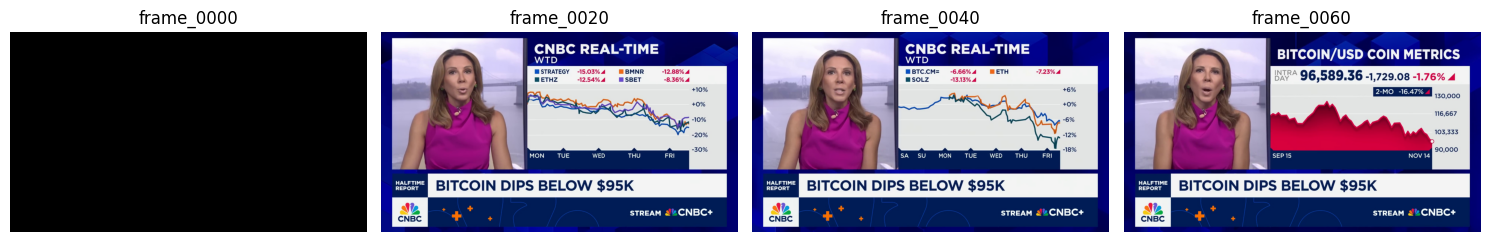

Showing 4 sample frames from 80 total frames


In [12]:
# View sample frames
show_sample_frames(FRAMES_DIR, num_samples=4)

## Step 3: Visual Analysis (OCR)

In [13]:
# Run OCR analysis
visual_summary = analyze_frames_with_ocr(
    frames_dir=FRAMES_DIR,
    confidence_threshold=0.3  # Adjust if needed
)

🔄 Initializing EasyOCR reader...
(Downloads model on first run - may take 1-2 minutes)
✅ OCR reader initialized

🔍 Analyzing 80 frames with OCR...
   Confidence threshold: 0.3



OCR Analysis:   0%|          | 0/80 [00:00<?, ?it/s]

c:\Users\helen\Desktop\CodeMonkey\AI_Practice\LEARNING_PROJECTS\video2text2summary\venv\lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



✅ OCR complete!
   Frames with text: 79/80
   Total text blocks: 1576

🔍 Analyzing patterns...
   Key terms found: 55
   Numbers found: 2019
   Key frames: 0


In [14]:
# Display OCR results
if visual_summary:
    display(Markdown("## 👁️ Visual Analysis Results"))
    display(Markdown(f"**Frames analyzed:** {visual_summary.total_frames}"))
    display(Markdown(f"**Frames with text:** {visual_summary.frames_with_text}"))
    display(Markdown(f"**Key terms detected:** {', '.join(visual_summary.detected_terms[:10])}"))
    display(Markdown(f"**Numbers found:** {len(visual_summary.numbers_found)}"))
    
    # Show some extracted numbers
    if visual_summary.numbers_found:
        display(Markdown("\n**Sample data points:**"))
        for num in visual_summary.numbers_found[:5]:
            display(Markdown(f"- {num['value']} (from: {num['context'][:50]}...)"))

## 👁️ Visual Analysis Results

**Frames analyzed:** 80

**Frames with text:** 79

**Key terms detected:** BELOW, BITCOIN, BITCOINJUSD, BMNR, BTC, BUSINESS, CM, CNBC, COIN, Crypto

**Numbers found:** 2019

...

- 95K (from: BITCOIN DIPS BELOW S95K...)

- 95 (from: BITCOIN DIPS BELOW S95K...)

- 95 (from: BITCOIN DIPS BELOW S95K...)

- $95K (from: BITCOIN DIPS BELOW $95K...)

- 95K (from: BITCOIN DIPS BELOW $95K...)

## Step 4: Text Analysis (NLP)

In [15]:
# Sample transcript (replace with actual transcript)
sample_transcript = """
Welcome to this Python programming tutorial. Today we'll cover data structures,
functions, and best practices for writing clean code.

First, let's discuss lists and dictionaries. Lists are ordered collections that
can store multiple items. For example, numbers = [1, 2, 3, 4, 5]. Dictionaries
store key-value pairs, which is useful for organizing related data.

Functions should do one thing well. We use the 'def' keyword to define them.
Always include docstrings explaining what each function does - this makes your
code maintainable.

Error handling is crucial. Use try-except blocks to handle potential errors
gracefully. This prevents crashes when something unexpected happens.

For performance, use list comprehensions instead of traditional loops. They make
code faster and more readable.

In conclusion, writing clean Python code involves understanding data structures,
writing focused functions, handling errors properly, and optimizing where needed.
"""

print("📝 Using sample transcript")
print(f"Length: {len(sample_transcript)} characters\n")

📝 Using sample transcript
Length: 962 characters



In [16]:
# Run NLP analysis
if OPENAI_API_KEY:
    text_summary = analyze_text_with_nlp(sample_transcript, client)
else:
    print("⚠️  OpenAI API key required for text analysis")

🤖 Running NLP Analysis...

1️⃣ Analyzing tone...
   Result: NEUTRAL

2️⃣ Generating summary...
   This Python programming tutorial covers data structures, functions, and best practices for writing clean code. It emphasizes the importance of understanding lists and dictionaries, writing focused functions with proper documentation, handling errors gracefully, and optimizing code for performance, particularly through the use of list comprehensions.

3️⃣ Extracting claims...
   Found 11 claims

4️⃣ Identifying entities...
   Found: Python, programming tutorial, data structures, functions, best practices...

5️⃣ Extracting key points...
   5 key points

✅ NLP analysis complete!


In [17]:
# Display NLP results
if 'text_summary' in locals():
    display(Markdown("## 💬 Text Analysis Results"))
    display(Markdown(f"**Tone:** {text_summary.tone}"))
    display(Markdown(f"**Summary:** {text_summary.summary}"))
    display(Markdown(f"**Entities found:** {', '.join(text_summary.entities)}"))
    display(Markdown(f"**Claims extracted:** {len(text_summary.claims)}"))
    
    if text_summary.key_points:
        display(Markdown("\n**Key Points:**"))
        for i, point in enumerate(text_summary.key_points, 1):
            display(Markdown(f"{i}. {point}"))

## 💬 Text Analysis Results

**Tone:** NEUTRAL

**Summary:** This Python programming tutorial covers data structures, functions, and best practices for writing clean code. It emphasizes the importance of understanding lists and dictionaries, writing focused functions with proper documentation, handling errors gracefully, and optimizing code for performance, particularly through the use of list comprehensions.

**Entities found:** Python, programming tutorial, data structures, functions, best practices, clean code, lists, dictionaries, numbers, key-value pairs, def keyword, docstrings, code maintainability, error handling, try-except blocks, performance, list comprehensions, traditional loops, code optimization

**Claims extracted:** 11

...

1. Understanding data structures like lists and dictionaries is crucial to writing clean Python code.

2. Functions in Python should be focused and do one thing well, and should always include docstrings to explain their purpose.

3. Error handling using try-except blocks is important to prevent crashes and handle potential errors gracefully.

4. Using list comprehensions instead of traditional loops can improve code performance and readability.

5. Writing clean Python code involves understanding data structures, writing focused functions, handling errors properly, and optimizing where needed.

## Step 5: Multi-Modal Fusion

In [18]:
# Fuse visual and text analysis
if visual_summary and 'text_summary' in locals():
    final_report = fuse_multimodal_data(
        video_name=video_path.name if video_path else "Unknown",
        visual_summary=visual_summary,
        text_summary=text_summary
    )
else:
    print("⚠️  Complete visual and text analysis first")

🔄 Fusing multi-modal data...

📊 Quality Score: 74.5/100
🏷️  Total unique entities: 74
💡 Generated 2 insights

✅ Multi-modal fusion complete!


## Step 6: View & Save Report

In [19]:
# Display complete report
if 'final_report' in locals():
    display_report(final_report)
else:
    print("⚠️  Generate report first")

# 📋 Multi-Modal Analysis Report

**Video:** Bitcoin crashes to six-month lows.mp4

**Analysis Date:** 2025-11-15T23:01:29.542130

---

## 📊 Quality Score: 🟢 74.5/100

...

## 🎬 Visual Analysis Statistics

- Total frames analyzed: 80

- Frames with text: 79

- Text blocks extracted: 1576

- Data points found: 2019

In [20]:
# Save report to files
if 'final_report' in locals():
    json_path, md_path = save_report(final_report, REPORTS_DIR)
    print(f"\n✅ Reports saved to {REPORTS_DIR}")
else:
    print("⚠️  No report to save")

✅ JSON report saved: data\output\reports\report_20251115_230129.json
✅ Markdown report saved: data\output\reports\report_20251115_230129.md

✅ Reports saved to data\output\reports


---

## ✨ Analysis Complete!

### What We Demonstrated:

1. ✅ **Computer Vision** - OCR with EasyOCR to extract text from frames
2. ✅ **Natural Language Processing** - GPT-4 to understand content
3. ✅ **Multi-Modal Fusion** - Combined visual + text analysis
4. ✅ **Production Pipeline** - Clean, modular architecture
5. ✅ **Data Export** - JSON and Markdown reports

### Key AI/ML Techniques:

- Deep learning for OCR (CRAFT + recognition network)
- Large language models for information extraction
- Pattern matching and regex for structured data
- Cross-modal correlation and data fusion
- Multi-criteria scoring and aggregation

### Files Generated:

- **Frames:** `data/output/frames/`
- **Reports:** `data/output/reports/`

---

**Perfect for demonstrating multi-modal AI in action!** 🎉
"""